In [1]:
import jax
import jax.numpy as jnp
import optax
from flax.training import train_state
from flax import linen as nn
from jax.scipy.integrate import trapezoid

In [2]:
# Define a simple MLP using Flax Linen
class MLP(nn.Module):
    architecture: list
    hidden_activation: callable = nn.tanh

    @nn.compact
    def __call__(self, x):
        for i in range(len(self.architecture) - 1):
            x = nn.Dense(features=self.architecture[i + 1])(x)
            if i < len(self.architecture) - 2:
                x = self.hidden_activation(x)
        return x

In [35]:
def laplace(func, x):
    """Compute the Laplace operator of the model output with respect to inputs."""
    grad_fn = jax.grad(func)
    d2_dx2 = 0
    for i in range(x.shape[1]):
        d2_dx2 += jax.vmap(jax.grad(lambda xi: grad_fn(xi)[i]))(x)[:, i]
    return d2_dx2

# compute kinetic term with AD (correct)
def local_energy_batch(params, xs, model_apply):
    # xs: (batch, 1) or (batch,)
    # psi(x) -> scalar
    def psi_fn(x):
        # ensure input has shape (1,) as model expects last-dim features
        x = jnp.atleast_1d(x).reshape(1, -1)  # (1, DoF)
        return model_apply(params, x).squeeze()

    # second derivative per sample via AD
    d2psi = laplace(psi_fn, xs)

    psi_vals = jax.vmap(lambda x: psi_fn(x))(xs)  # shape (batch,)

    # avoid division by zero / small psi
    psi_safe = psi_vals + 1e-12

    kinetic = -0.5 * (d2psi / psi_safe)  # shape (batch,)
    # potential = 0.5 * (xs_flat**2)  # shape (batch,)
    potential = 0.5 * jnp.sum(xs**2, axis=1)
    return (kinetic + potential).reshape(-1, 1)  # keep your (batch,1) convention

def log_psi(x, params, model_apply):
    psi = model_apply(params, x)
    return jnp.log(jnp.abs(psi) + 1e-8)  # Add small constant to avoid log(0)

grad_log_psi = jax.grad(lambda params, x, model_apply: log_psi(x, params, model_apply), argnums=0) # CAREFUL WITH THE DERIVATIVES: WE WANT THE GRADIENT WRT THE PARAMETERS, so we turn the order of the p and x

def log_psi_and_grad(params, x, model_apply):
    psi = model_apply(params, x)
    log_psi_val = jnp.log(jnp.abs(psi) + 1e-8)
    grad_log_psi_val = grad_log_psi(params, x, model_apply)
    return log_psi_val, grad_log_psi_val

def energy_fn(params, batch, model_apply):
    psi = jax.vmap(lambda x: model_apply(params, x))(batch)
    psi_squared = jnp.abs(psi)**2
    print("psi shape")
    print(psi.shape)
    local_energy_per_point = local_energy_batch(params, batch, model_apply)
    print("E_loc shape")
    print(local_energy_per_point.shape)
    energy_integrand = psi_squared * local_energy_per_point
    norm = trapezoid(psi_squared.squeeze(), batch.squeeze())
    integral = trapezoid(energy_integrand.squeeze(), batch.squeeze())
    return integral / norm 

def loss_and_grads(params, batch, model_apply):
    E = energy_fn(params, batch, model_apply)
    grad_E = jax.grad(energy_fn, argnums=0)(params, batch, model_apply)
    return E, grad_E

@jax.jit
def train_step(state, batch):
    E, grads = loss_and_grads(state.params, batch, state.apply_fn)
    new_state = state.apply_gradients(grads=grads)
    return new_state, E

def train(n_steps, init_params, model_apply, optimizer, points):

    state = train_state.TrainState.create(
        apply_fn=model_apply,
        params=init_params,
        tx=optimizer
    )

    energy_history = []
    batch = points

    for step in range(n_steps):
        # batch = sampler(state.params, state.apply_fn)
        state, energy = train_step(state, batch)
        energy_history.append(energy)

        if step % 100 == 0:
            print(f"Step {step}, Energy: {energy}")

    return state.params, energy_history

In [ ]:
BATCH_SIZE = 50

x = jnp.linspace(-5,5,BATCH_SIZE)
y = jnp.linspace(-5,5,BATCH_SIZE)

points = jnp.stack([x,y], axis=1)
print(points.shape)

input_shape = (BATCH_SIZE, 2)

X, Y = jnp.meshgrid(x,y)

print(X)
print(X.ravel())

coords = jnp.stack([X.ravel(), Y.ravel()]).transpose()

print(coords.shape)

rng_key = jax.random.PRNGKey(0)

model = MLP(architecture=[2,10,1])
params = model.init(rng_key, jnp.ones(input_shape))
params_fin, energy = train(1000, params, model.apply, optax.adam(1e-3), points = coords )


(50, 2)
[[-5.        -4.7959185 -4.591837  ...  4.591836   4.795918   5.       ]
 [-5.        -4.7959185 -4.591837  ...  4.591836   4.795918   5.       ]
 [-5.        -4.7959185 -4.591837  ...  4.591836   4.795918   5.       ]
 ...
 [-5.        -4.7959185 -4.591837  ...  4.591836   4.795918   5.       ]
 [-5.        -4.7959185 -4.591837  ...  4.591836   4.795918   5.       ]
 [-5.        -4.7959185 -4.591837  ...  4.591836   4.795918   5.       ]]
[-5.        -4.7959185 -4.591837  ...  4.591836   4.795918   5.       ]
(2500, 2)
psi shape
(2500, 1)
E_loc shape
(2500, 1)
psi shape
(2500, 1)
E_loc shape
(2500, 1)


TypeError: Gradient only defined for scalar-output functions. Output had shape: (2500,).

ERROR:tornado.general:Uncaught exception in ZMQStream callback
Traceback (most recent call last):
  File "/home/pfargas/software/anaconda3/envs/jax/lib/python3.13/site-packages/zmq/eventloop/zmqstream.py", line 565, in _log_error
    f.result()
    ~~~~~~~~^^
  File "/home/pfargas/software/anaconda3/envs/jax/lib/python3.13/site-packages/ipykernel/kernelbase.py", line 302, in dispatch_control
    await self.process_control(msg)
  File "/home/pfargas/software/anaconda3/envs/jax/lib/python3.13/site-packages/ipykernel/kernelbase.py", line 308, in process_control
    idents, msg = self.session.feed_identities(msg, copy=False)
                  ~~~~~~~~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^
  File "/home/pfargas/software/anaconda3/envs/jax/lib/python3.13/site-packages/jupyter_client/session.py", line 994, in feed_identities
    raise ValueError(msg)
ValueError: DELIM not in msg_list
ERROR:tornado.general:Uncaught exception in ZMQStream callback
Traceback (most recent call last):
  File "/home

Step 0, Energy: 2.8549797534942627
Step 100, Energy: 0.8988254070281982
Step 200, Energy: 0.5831892490386963
Step 300, Energy: 0.5466018319129944
Step 400, Energy: 0.5308383703231812
Step 500, Energy: 0.5220752358436584
Step 600, Energy: 0.5162575244903564
Step 700, Energy: 0.5119786262512207
Step 800, Energy: 0.5087947249412537
Step 900, Energy: 0.5065177083015442


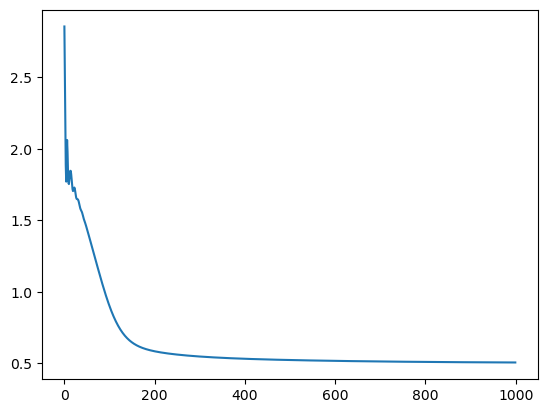

<class 'jaxlib._jax.ArrayImpl'>
(1000, 1)
Norm: 0.4933973252773285
Norm after normalization: 1.0


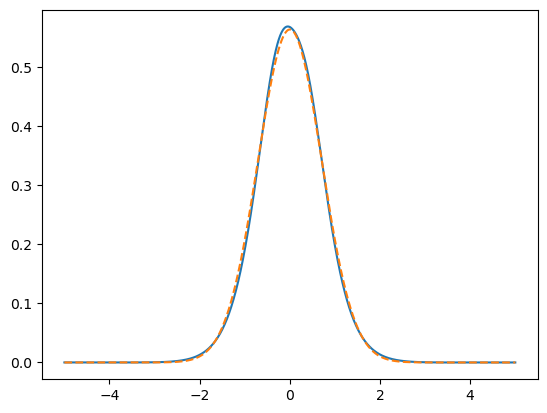

In [4]:
model = MLP(architecture=[1, 30, 1])
rng = jax.random.PRNGKey(0)
input_shape = (1000, 1)  # Batch size of 1000, input dimension
params = model.init(rng, jnp.ones(input_shape))  # Initialize parameters
params_fin, energy = train(1000, params, model.apply, optax.adam(1e-3))
import matplotlib.pyplot as plt
plt.plot(energy)
plt.show()

# Reconstruct wavefunction
x = jnp.linspace(-5,5,1000).reshape(-1,1)
psi_approx = model.apply(params_fin, x)
print(type(psi_approx))
print(psi_approx.shape)
norm = jnp.sqrt(trapezoid((psi_approx**2).squeeze(), x.squeeze()))
print(f"Norm: {norm}")
psi_approx = psi_approx / norm
print(f"Norm after normalization: {jnp.sqrt(trapezoid((psi_approx**2).squeeze(), x.squeeze()))}")
plt.plot(x, psi_approx**2)
plt.plot(x, jnp.pi**(-0.5)*jnp.exp(-x**2), linestyle='dashed')